In [2]:
import os
import librosa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
import tensorflow as tf
#libraries for building the model
from tensorflow.keras.layers import BatchNormalization, Conv2D,MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [6]:
##loading the other data(mel's) and lables
vocal_data = np.load(f'processed_data/vocal_features.npy')
vocal_labels = np.load(f'processed_data/vocal_labels.npy')

In [7]:
print(vocal_data.shape)
print(vocal_labels.shape)

(9657, 150, 150, 1)
(9657,)


### 3 Way data split

In [8]:
# shuffling is need cause we added the data in a sequential order first bollypop then carnatic so data inside data is in order
#stratify keep the proportion of data same in both test and train
from sklearn.model_selection import train_test_split

# this single line splits and shuffles at the same time
X_train, X_temp, Y_train, Y_temp = train_test_split(
    vocal_data,
    vocal_labels,
    test_size=0.2,
    random_state=42,
    shuffle=True, # be default it is true
    stratify=vocal_labels # Ensures 20% of EACH genre goes to the test set
)


#20 % remaining data in temp
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True, # be default it is true
    stratify= Y_temp # Ensures 20% of EACH genre goes to the test set
)
# Summary of the "Shuffling" Timeline
# During Split: Handled by train_test_split(shuffle=True). (Do this now)
# During Training: Handled by model.fit(shuffle=True). (Do this later)
# now ready for normalization

In [9]:
print(X_train.shape)
print(Y_train.shape)
print(X_val.shape)
print(Y_val.shape)
print(X_test.shape)
print(Y_test.shape)

(7725, 150, 150, 1)
(7725,)
(966, 150, 150, 1)
(966,)
(966, 150, 150, 1)
(966,)


## Data Normalization

In [10]:
# 1. Calculate stats from TRAINING data only
# This represents the "known world" to the model
# min and max of x_train only
X_min = X_train.min()
X_max = X_train.max()

# 2. Apply the same scaling to all three sets
# This squishes all dB values into a 0.0 to 1.0 range
X_train = (X_train - X_min) / (X_max - X_min)
X_val = (X_val - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

# 3. Verification - Essential Check!
print("--- Normalization Audit ---")
print(f"Train Range: {X_train.min()} to {X_train.max()}") # Must be 0.0 to 1.0
print(f"Val Range:   {X_val.min():.2f} to {X_val.max():.2f}")
print(f"Test Range:  {X_test.min():.2f} to {X_test.max():.2f}")

--- Normalization Audit ---
Train Range: 0.0 to 1.0
Val Range:   0.00 to 1.00
Test Range:  0.00 to 1.00


In [7]:
# consists of convulations, pooling, flatening(fully connected), dense and dropout
# using the sequential modle(layer stacking)
# allows group layers together and the output of one layers is the input for other layer

model = tf.keras.models.Sequential()


In [25]:
classes = ['bollypop', 'carnatic', 'ghazal', 'semiclassical', 'sufi']

In [9]:
mel_shape = X_train[0].shape
#it is just the one melspectrogram(one chunk out of multiple chunks of one audio file)
#and it has 210*210 - 44100 elements

## Adding the layers

In [10]:
# block 1
model.add(Conv2D(filters = 32, kernel_size= 3, padding= 'same', activation= 'relu', input_shape = mel_shape ))
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters= 32, kernel_size = 3, activation = 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size=2, strides = 2))


          

In [11]:
# block 2
model.add(Conv2D(filters= 64, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
                                                                                    # same as first layers(no need to give again)
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters = 64, kernel_size = 3, activation= 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size = 2, strides = 2))

In [12]:
# block 3
model.add(Conv2D(filters= 128, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
                                                                                    # same as first layers(no need to give again)
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters = 128, kernel_size = 3, activation= 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size = 2, strides = 2))

In [13]:
# drop some features to overcome overfitting

model.add(Dropout(0.3)) #-> dropping 30% neurons

In [14]:
# block 4
model.add(Conv2D(filters= 256, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
                                                                                    # same as first layers(no need to give again)
model.add(BatchNormalization()) # Added

model.add(Conv2D(filters = 256, kernel_size = 3, activation= 'relu'))
model.add(BatchNormalization()) # Added

model.add(MaxPool2D(pool_size = 2, strides = 2))

In [15]:
# #block 6
# model.add(Conv2D(filters= 512, kernel_size = 3, padding = 'same', activation= 'relu')) #input shape will be there 
#                                                                                     # same as first layers(no need to give again)
# model.add(Conv2D(filters = 512, kernel_size = 3, activation= 'relu'))

# model.add(MaxPool2D(pool_size = 2, strides = 2))


In [17]:
model.add(Dropout(0.4))

#### Flatten and Dense

In [18]:
model.add(Flatten())
# Fully Connected (FC)The fully connected layer (FC) operates on a flattened input where each input is 
# connected to all neurons. If present, FC layers are usually found towards the end of CNN architectures
# and can be used to optimize objectives such as class scores.

In [19]:
#constructing the hidden layers, units are neuron and value activation func is relu(as sigmoid is costly(may be on CPU resourses)
model.add(Dense(units = 512, activation = 'relu'))

In [20]:
model.add(Dropout(0.5))

In [21]:
#final output layer
model.add(Dense(units=len(classes), activation = 'softmax'))

In [22]:
model.summary()
# The parameters here are the extracted features from the mel's by conv2d(extraction), pooling(max,avg value extraction)
# and the dropout(removal) again repeating and increasing filters , hence it just increases

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 148, 148, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                        

### Compiling the Model

In [23]:
model.compile(optimizer = Adam(learning_rate = 0.0001), loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])
#loss = sparse_categorical_crossentropy, no one hot encoding needed

## Training the Model

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Stop if the model doesn't improve for 8 epochs
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=8, 
    restore_best_weights=True # This is the most important part!
)

# 2. Lower learning rate if progress stalls (helps get that extra 2-3%)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=4, 
    min_lr=0.00001
)

In [25]:
training_history = model.fit(
    X_train, Y_train,
    epochs= 50,
    batch_size= 64,
    validation_data=(X_val, Y_val),
    callbacks=[early_stopping, reduce_lr]
    )

Epoch 1/50
121/121 [==============================] - 35s 219ms/step - loss: 2.3124 - accuracy: 0.3544 - val_loss: 4.7471 - val_accuracy: 0.1584 - lr: 1.0000e-04
Epoch 2/50
121/121 [==============================] - 22s 182ms/step - loss: 1.3211 - accuracy: 0.4497 - val_loss: 8.7824 - val_accuracy: 0.2122 - lr: 1.0000e-04
Epoch 3/50
121/121 [==============================] - 22s 182ms/step - loss: 1.1831 - accuracy: 0.5115 - val_loss: 7.4582 - val_accuracy: 0.2122 - lr: 1.0000e-04
Epoch 4/50
121/121 [==============================] - 22s 182ms/step - loss: 1.1071 - accuracy: 0.5417 - val_loss: 3.2568 - val_accuracy: 0.2164 - lr: 1.0000e-04
Epoch 5/50
121/121 [==============================] - 22s 182ms/step - loss: 1.0276 - accuracy: 0.5768 - val_loss: 1.7894 - val_accuracy: 0.3685 - lr: 1.0000e-04
Epoch 6/50
121/121 [==============================] - 22s 181ms/step - loss: 0.9609 - accuracy: 0.6028 - val_loss: 0.9464 - val_accuracy: 0.6139 - lr: 1.0000e-04
Epoch 7/50
121/121 [========

In [26]:
# 19m 17s for vocal train

In [27]:
# Save in the modern Keras format
model.save('indian_music_classifier_vocal.keras') 
print("Model saved as indian_music_classifier_vocal.keras")

Model saved as indian_music_classifier_vocal.keras


In [28]:
training_history.history
# model

{'loss': [2.3123691082000732,
  1.3211250305175781,
  1.1830952167510986,
  1.1070516109466553,
  1.0275559425354004,
  0.9608989953994751,
  0.9163817167282104,
  0.8838691711425781,
  0.8156154155731201,
  0.785467803478241,
  0.7461203336715698,
  0.7105382084846497,
  0.6787170767784119,
  0.6382297277450562,
  0.6033704280853271,
  0.5957460999488831,
  0.575563371181488,
  0.5169495940208435,
  0.5158951878547668,
  0.46961483359336853,
  0.4491892457008362,
  0.4403398633003235,
  0.40767061710357666,
  0.38402849435806274,
  0.36979028582572937,
  0.33625438809394836,
  0.32622596621513367,
  0.30851975083351135,
  0.2749556303024292,
  0.2679223120212555,
  0.26622238755226135,
  0.2499324083328247,
  0.23618437349796295,
  0.21867918968200684,
  0.1969122737646103,
  0.1537550985813141,
  0.14203454554080963,
  0.1416943371295929,
  0.13699355721473694,
  0.12767763435840607,
  0.11974500119686127,
  0.12471751868724823,
  0.10912930220365524,
  0.10572108626365662,
  0.10920

In [30]:
# big float value error of lr in the last
import json
import numpy as np

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super(NumpyEncoder, self).default(obj)

# Now saving is a one-liner
with open('training_hist_vocal.json', 'w') as f:
    json.dump(training_history.history, f, cls=NumpyEncoder, indent=4)

## Model Evaluation

In [11]:
model = tf.keras.models.load_model("indian_music_classifier_vocal.keras")
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 150, 150, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 batch_normalization_1 (Batc  (None, 148, 148, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                        

In [12]:
import json
with open('training_hist_vocal.json', 'r') as json_file:
    training_history = json.load(json_file)

training_history.keys() #it is a dictionary now

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

## Evaluation on train and test data

In [13]:
training_loss ,training_accuracy = model.evaluate(X_train, Y_train)

242/242 [==============================] - 14s 30ms/step - loss: 0.0232 - accuracy: 0.9948


In [14]:
val_loss ,val_accuracy = model.evaluate(X_val, Y_val)

31/31 [==============================] - 1s 40ms/step - loss: 0.3170 - accuracy: 0.8965


In [15]:
training_history['loss']

[2.3123691082000732,
 1.3211250305175781,
 1.1830952167510986,
 1.1070516109466553,
 1.0275559425354004,
 0.9608989953994751,
 0.9163817167282104,
 0.8838691711425781,
 0.8156154155731201,
 0.785467803478241,
 0.7461203336715698,
 0.7105382084846497,
 0.6787170767784119,
 0.6382297277450562,
 0.6033704280853271,
 0.5957460999488831,
 0.575563371181488,
 0.5169495940208435,
 0.5158951878547668,
 0.46961483359336853,
 0.4491892457008362,
 0.4403398633003235,
 0.40767061710357666,
 0.38402849435806274,
 0.36979028582572937,
 0.33625438809394836,
 0.32622596621513367,
 0.30851975083351135,
 0.2749556303024292,
 0.2679223120212555,
 0.26622238755226135,
 0.2499324083328247,
 0.23618437349796295,
 0.21867918968200684,
 0.1969122737646103,
 0.1537550985813141,
 0.14203454554080963,
 0.1416943371295929,
 0.13699355721473694,
 0.12767763435840607,
 0.11974500119686127,
 0.12471751868724823,
 0.10912930220365524,
 0.10572108626365662,
 0.10920250415802002,
 0.10366502404212952,
 0.10022030770778

## Accuracy and loss visualization

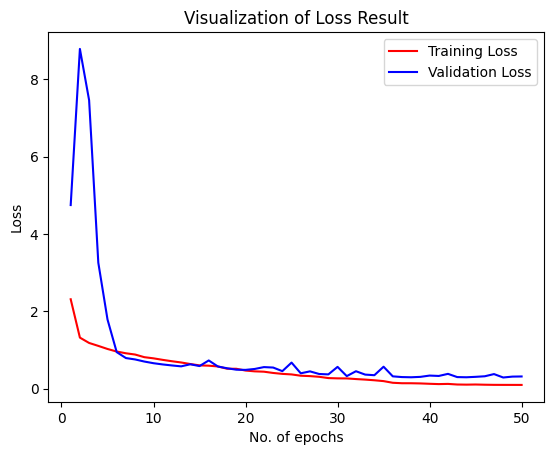

In [16]:
epochs = [i for i in range(1,51)]
plt.plot(epochs, training_history['loss'], label = 'Training Loss',color = 'red' ) 
plt.plot(epochs, training_history['val_loss'], label = 'Validation Loss',color = 'blue' )
plt.xlabel('No. of epochs')
plt.ylabel('Loss')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

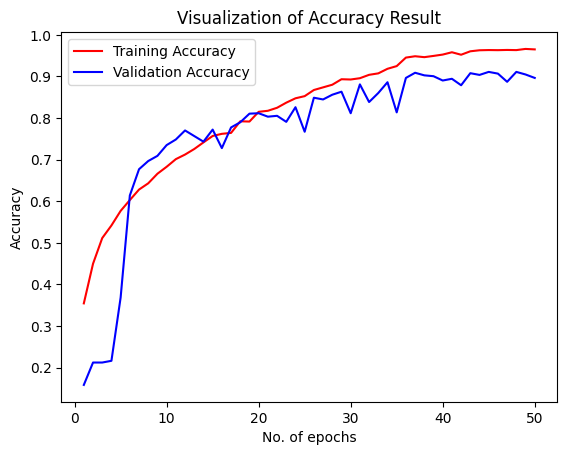

In [18]:
epochs = [i for i in range(1,51)]
plt.plot(epochs, training_history['accuracy'], label = 'Training Accuracy',color = 'red' ) 
plt.plot(epochs, training_history['val_accuracy'], label = 'Validation Accuracy',color = 'blue' )
plt.xlabel('No. of epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Precision, Recall and Confusion Matrix

In [19]:
X_test.shape

(966, 150, 150, 1)

In [20]:
y_pred = model.predict(X_test)

#y_pred the predicted labels, y_test the actual labels
y_pred

31/31 [==============================] - 1s 37ms/step


array([[3.9194950e-09, 9.2378087e-07, 2.3441500e-07, 1.0696687e-04,
        9.9989188e-01],
       [1.5716975e-11, 6.5409061e-13, 1.0000000e+00, 1.7348816e-12,
        3.2063175e-11],
       [8.3464130e-08, 4.6426177e-08, 1.3544503e-09, 5.7792398e-03,
        9.9422061e-01],
       ...,
       [5.1091705e-02, 6.4304362e-13, 7.2210439e-17, 1.3944635e-03,
        9.4751382e-01],
       [1.3215140e-05, 7.3872656e-07, 7.0325274e-09, 2.6106095e-06,
        9.9998343e-01],
       [7.4684310e-01, 1.7805293e-02, 6.8824030e-03, 2.0663863e-01,
        2.1830540e-02]], dtype=float32)

In [21]:
predicted_categories = np.argmax(y_pred, axis = 1)
predicted_categories


# axis = 0
# predicted_categories = np.argmax(y_pred, axis = 0)
# predicted_categories

array([4, 2, 4, 4, 3, 3, 3, 4, 3, 2, 1, 2, 0, 1, 4, 0, 3, 0, 0, 2, 3, 0,
       2, 0, 4, 1, 1, 3, 3, 0, 3, 2, 1, 0, 2, 0, 1, 4, 0, 0, 4, 4, 1, 1,
       3, 0, 4, 0, 0, 4, 4, 3, 0, 2, 4, 4, 4, 3, 4, 0, 0, 3, 1, 4, 4, 1,
       4, 4, 1, 2, 0, 0, 0, 0, 0, 2, 0, 1, 0, 3, 1, 4, 1, 0, 3, 2, 2, 2,
       1, 4, 1, 3, 4, 1, 3, 0, 3, 0, 3, 0, 2, 0, 2, 1, 4, 2, 4, 0, 3, 0,
       2, 3, 1, 4, 4, 3, 2, 3, 2, 3, 4, 0, 1, 4, 4, 1, 2, 0, 4, 0, 1, 0,
       4, 2, 1, 1, 2, 2, 0, 3, 1, 2, 3, 1, 4, 3, 1, 0, 4, 3, 0, 1, 0, 2,
       3, 4, 4, 0, 3, 0, 0, 2, 1, 0, 0, 1, 1, 2, 4, 3, 0, 4, 2, 0, 1, 2,
       4, 2, 3, 4, 0, 1, 0, 2, 2, 2, 1, 1, 0, 0, 2, 0, 0, 0, 1, 3, 0, 1,
       2, 0, 0, 1, 0, 1, 0, 0, 0, 4, 2, 2, 0, 0, 0, 4, 3, 4, 2, 2, 0, 3,
       4, 0, 2, 0, 2, 0, 3, 0, 3, 0, 0, 4, 0, 3, 2, 0, 2, 1, 1, 3, 4, 2,
       1, 3, 2, 0, 0, 4, 2, 2, 0, 0, 1, 1, 2, 0, 0, 3, 1, 2, 4, 4, 1, 0,
       0, 2, 1, 4, 3, 0, 3, 0, 2, 2, 3, 4, 4, 3, 4, 4, 3, 4, 4, 1, 4, 1,
       1, 4, 4, 0, 4, 4, 3, 0, 4, 1, 2, 0, 1, 0, 2,

In [22]:
print(Y_test)
print(predicted_categories)        #now we have both true and predicted labels in a single array

[4 2 4 4 3 3 3 4 3 2 1 2 4 1 4 0 3 3 0 2 4 0 2 0 4 1 1 3 3 0 3 2 1 0 2 0 1
 3 0 0 3 4 1 1 3 0 4 0 0 4 4 3 0 2 4 4 4 3 4 0 0 3 1 3 4 1 4 4 1 2 0 0 0 0
 0 2 0 1 0 3 1 4 1 0 3 2 2 2 1 4 1 3 4 1 3 0 3 0 3 0 2 0 2 1 4 2 4 0 3 0 2
 1 1 4 4 4 2 3 2 3 4 0 1 4 4 1 2 0 4 0 1 3 3 2 1 1 2 2 0 3 1 2 3 1 2 3 1 0
 3 1 0 1 0 2 3 4 4 0 3 0 0 2 1 0 0 1 1 2 4 3 0 4 2 0 1 2 4 2 3 4 0 1 0 2 2
 2 1 1 0 0 2 0 0 0 1 3 0 1 2 3 3 1 0 1 0 0 0 4 2 2 0 0 3 4 3 4 2 2 0 3 4 0
 2 0 2 0 3 0 3 0 0 4 0 3 2 3 2 1 1 3 4 2 1 3 2 0 0 4 2 2 0 0 1 1 2 0 0 3 1
 2 4 4 1 0 4 2 1 4 3 0 3 0 2 2 3 4 4 3 4 4 3 4 4 1 4 1 1 3 4 0 4 4 4 0 4 4
 2 0 1 3 2 0 4 3 1 1 3 1 1 3 0 4 3 4 4 0 3 2 2 3 3 1 0 3 0 3 0 0 1 1 0 0 2
 1 3 2 4 3 1 1 1 4 1 1 0 0 4 1 0 2 0 4 3 1 1 0 4 1 3 4 1 1 4 4 1 1 1 0 3 3
 4 1 0 0 0 0 0 0 2 4 0 1 0 4 3 1 1 2 0 0 4 0 1 4 0 0 0 3 3 3 4 3 3 0 1 4 4
 4 1 0 4 2 3 0 2 4 1 0 1 3 1 0 1 0 1 3 3 3 4 2 4 0 3 3 4 1 1 2 3 3 2 0 0 3
 1 1 4 4 2 4 0 0 1 3 4 1 2 0 3 3 4 4 0 0 2 0 3 2 1 1 0 1 3 1 0 1 2 2 3 2 0
 3 4 0 3 0 4 3 3 2 3 4 1 

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(
    Y_test,
    predicted_categories,
)

cm

array([[200,   0,   0,   3,   2],
       [  4, 185,   4,   8,   0],
       [  1,   0, 151,   0,   1],
       [ 26,   3,   4, 150,  20],
       [  6,   4,   1,   7, 186]], dtype=int64)

In [26]:
print(classification_report(Y_test, predicted_categories,target_names=classes))

               precision    recall  f1-score   support

     bollypop       0.84      0.98      0.90       205
     carnatic       0.96      0.92      0.94       201
       ghazal       0.94      0.99      0.96       153
semiclassical       0.89      0.74      0.81       203
         sufi       0.89      0.91      0.90       204

     accuracy                           0.90       966
    macro avg       0.91      0.91      0.90       966
 weighted avg       0.90      0.90      0.90       966



## Confusion Matrix Visualization

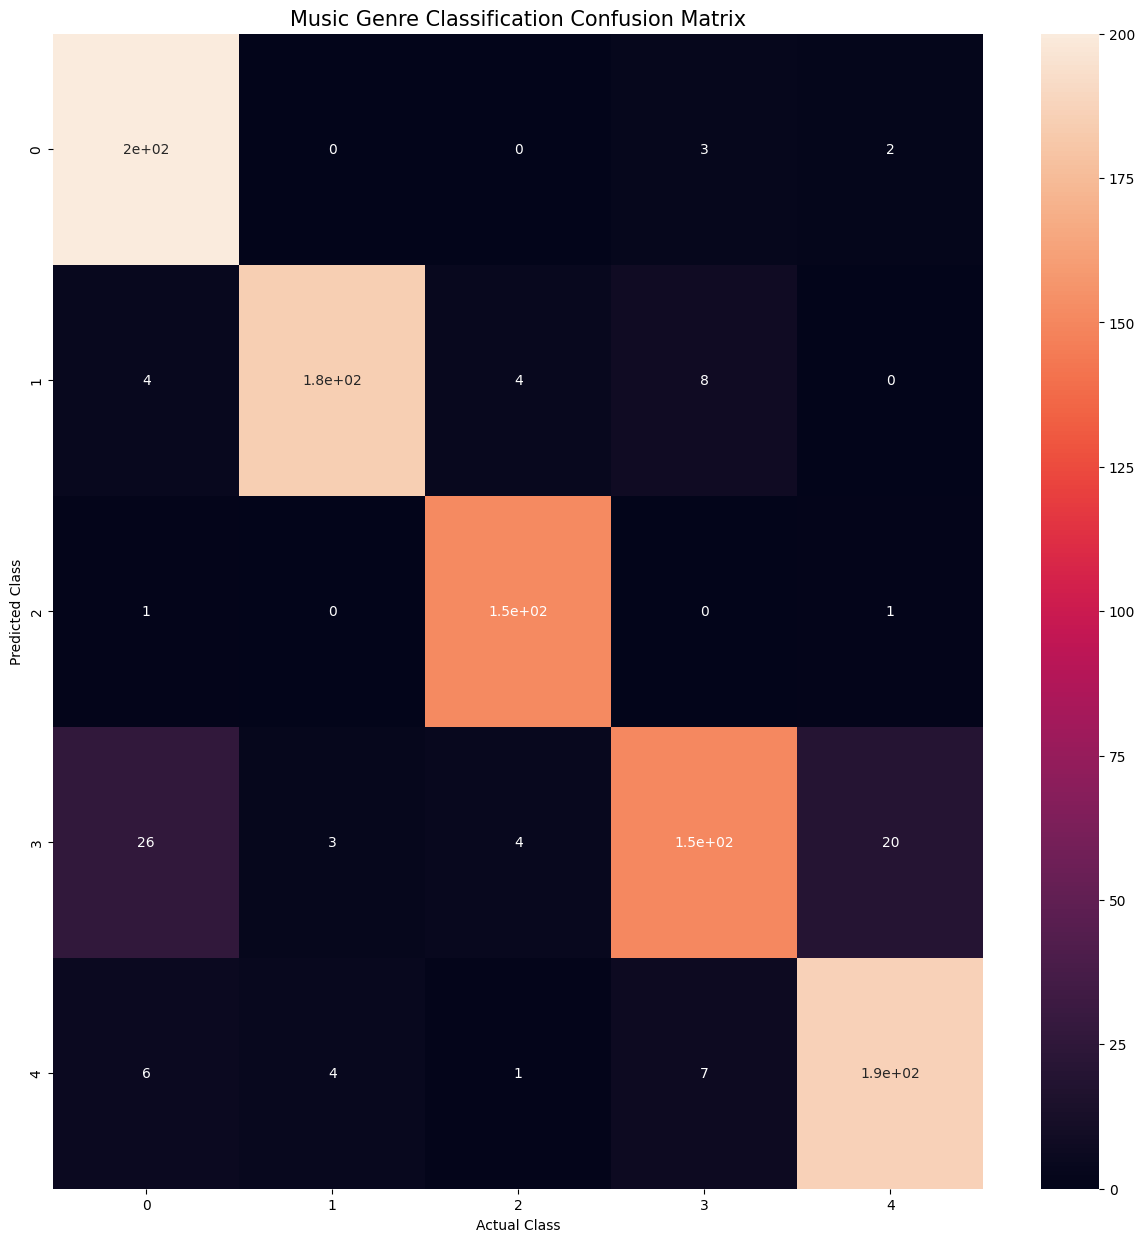

In [27]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size" : 10})
plt.ylabel("Predicted Class",fontsize=10)
plt.xlabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()

In [ ]:
# most of the values are in the diagonal means the performance of the model is good
# to improve the performance more we have to tune the model(on the parameters discussed earlier)